In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt

In [ ]:
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
baseline_model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

baseline_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8632 - loss: 0.4698 - val_accuracy: 0.9563 - val_loss: 0.1514
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9635 - loss: 0.1191 - val_accuracy: 0.9655 - val_loss: 0.1084
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9763 - loss: 0.0783 - val_accuracy: 0.9695 - val_loss: 0.0991
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9836 - loss: 0.0522 - val_accuracy: 0.9733 - val_loss: 0.0883
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9866 - loss: 0.0432 - val_accuracy: 0.9697 - val_loss: 0.1046
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9890 - loss: 0.0356 - val_accuracy: 0.9758 - val_loss: 0.0910
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9912 - loss: 0.0269 - val_accuracy: 0.9717 - val_loss: 0.1039
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9923 - loss: 0.0225 - 

In [ ]:
dropout_model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

dropout_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

history_dropout = dropout_model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6770 - loss: 0.9792 - val_accuracy: 0.9403 - val_loss: 0.2095
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8988 - loss: 0.3606 - val_accuracy: 0.9538 - val_loss: 0.1592
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9172 - loss: 0.2952 - val_accuracy: 0.9574 - val_loss: 0.1482
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9280 - loss: 0.2636 - val_accuracy: 0.9624 - val_loss: 0.1316
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9369 - loss: 0.2247 - val_accuracy: 0.9663 - val_loss: 0.1216
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9365 - loss: 0.2210 - val_accuracy: 0.9667 - val_loss: 0.1208
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9402 - loss: 0.2092 - val_accuracy: 0.9679 - val_loss: 0.1169
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9428 - loss: 0.2011 - 

In [ ]:
l2_model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(10, activation='softmax')
])

l2_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history_l2 = l2_model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8601 - loss: 0.6736 - val_accuracy: 0.9557 - val_loss: 0.3016
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9564 - loss: 0.2872 - val_accuracy: 0.9581 - val_loss: 0.2672
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9641 - loss: 0.2423 - val_accuracy: 0.9653 - val_loss: 0.2320
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9687 - loss: 0.2136 - val_accuracy: 0.9671 - val_loss: 0.2120
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9712 - loss: 0.1989 - val_accuracy: 0.9707 - val_loss: 0.1967
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9730 - loss: 0.1889 - val_accuracy: 0.9701 - val_loss: 0.1960
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9740 - loss: 0.1810 - val_accuracy: 0.9694 - val_loss: 0.1915
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9759 - loss: 0.1731 - 

In [ ]:
batchnorm_model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(10, activation='softmax')
])

batchnorm_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

history_batchnorm = batchnorm_model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8618 - loss: 0.4804 - val_accuracy: 0.9589 - val_loss: 0.1367
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9623 - loss: 0.1258 - val_accuracy: 0.9689 - val_loss: 0.1031
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9712 - loss: 0.0907 - val_accuracy: 0.9729 - val_loss: 0.0877
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9772 - loss: 0.0729 - val_accuracy: 0.9721 - val_loss: 0.0920
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9818 - loss: 0.0571 - val_accuracy: 0.9747 - val_loss: 0.0835
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9846 - loss: 0.0480 - val_accuracy: 0.9756 - val_loss: 0.0803
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9857 - loss: 0.0434 - val_accuracy: 0.9747 - val_loss: 0.0842
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9863 - loss: 0.0400 - 

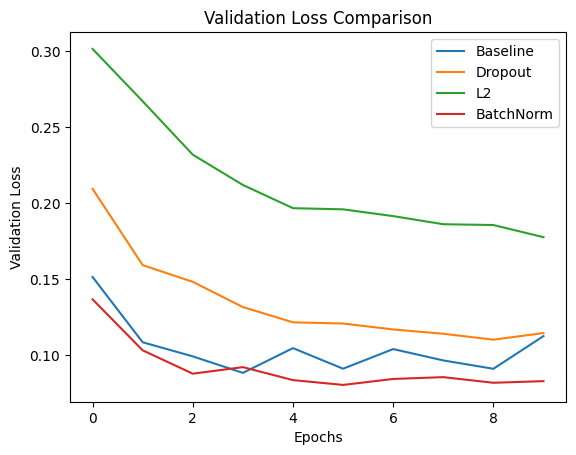

In [ ]:
plt.plot(history_baseline.history['val_loss'], label='Baseline')
plt.plot(history_dropout.history['val_loss'], label='Dropout')
plt.plot(history_l2.history['val_loss'], label='L2')
plt.plot(history_batchnorm.history['val_loss'], label='BatchNorm')

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.title("Validation Loss Comparison")
plt.show()


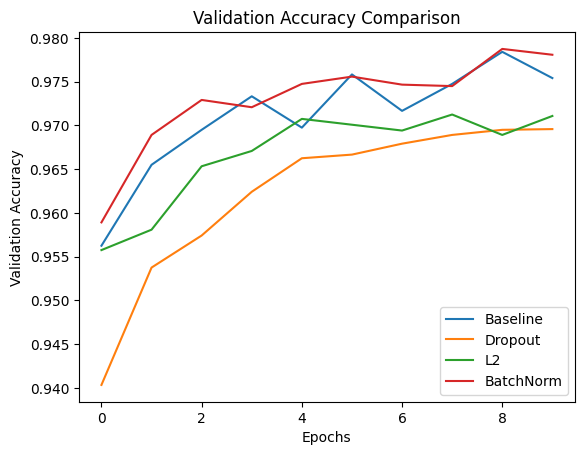

In [ ]:
plt.plot(history_baseline.history['val_accuracy'], label='Baseline')
plt.plot(history_dropout.history['val_accuracy'], label='Dropout')
plt.plot(history_l2.history['val_accuracy'], label='L2')
plt.plot(history_batchnorm.history['val_accuracy'], label='BatchNorm')

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Validation Accuracy Comparison")
plt.show()
